# IDD YOLO Segmentation Pipeline (Colab)
This notebook implements the complete pipeline for training a lightweight YOLO segmentation model on the IDD dataset for Indian unstructured roads.

## Phase 1: Environment Setup & GPU Check
Run this cell to install dependencies, mount Google Drive, and configure paths.


In [9]:
import os

print(os.listdir('/content/drive/MyDrive/SIH_Epilgoue/Dataset/IDD_Segmentation'))

['gtFine', 'idd_yolo_segmentation_colab.ipynb', 'generate_notebook.py', 'segmentation_implementation_plan.md', 'idd_segmentation_audit_report.md', 'leftImg8bit']


In [10]:
# 1. Environment Setup & GPU Check
import os
import sys
import json
import glob
import shutil
import random
import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from datetime import datetime

# Check GPU
!nvidia-smi

# Install YOLO
!pip install ultralytics

import ultralytics
print("Ultralytics version:", ultralytics.__version__)

import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DATASET_ROOT = "/content/drive/MyDrive/SIH_Epilgoue/Dataset/IDD_Segmentation"
OUTPUT_ROOT = "/content/drive/MyDrive/SIH_Epilgoue/Dataset/IDD_YOLO_SEG"
SUBSET_SIZE_TRAIN = 2000
SUBSET_SIZE_VAL = 400
IMAGE_SIZE = 640  # Fallback to 512 if OOM
BATCH_SIZE = 16   # Reduce to 8 if OOM
EPOCHS = 30
CONF_THRESHOLD = 0.25
MODEL_NAME = "yolo11n-seg.pt"  # Fallback to yolov8n-seg.pt if needed

os.makedirs(OUTPUT_ROOT, exist_ok=True)
print(f"Output directory created at {OUTPUT_ROOT}")


Thu Aug 27 02:59:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Phase 2: Source Dataset Inspection & Class Discovery
We extract every unique class present in the original dataset's JSON annotations to establish a ground truth.


In [11]:
# 2. Source dataset inspection
def get_all_json_files(base_dir):
    json_files = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('_gtFine_polygons.json'):
                json_files.append(os.path.join(root, file))
    return json_files

gt_dir = os.path.join(DATASET_ROOT, "gtFine")
if not os.path.exists(gt_dir):
    print(f"WARNING: Dataset root {gt_dir} not found. Ensure dataset is mounted/downloaded.")
else:
    all_jsons = get_all_json_files(gt_dir)
    print(f"Found {len(all_jsons)} total annotation JSON files.")

    source_classes = {}
    class_images = {}

    # Randomly sample a subset of JSONs to speed up discovery, or parse all if fast enough
    # Here we parse all to be perfectly accurate
    print("Parsing annotations for class discovery...")
    for jf in tqdm(all_jsons):
        try:
            with open(jf, 'r') as f:
                data = json.load(f)

            img_classes = set()
            for obj in data.get('objects', []):
                label = obj.get('label')
                # Ignore deleted objects if flagged
                if obj.get('deleted', 0) == 1:
                    continue
                if label not in source_classes:
                    source_classes[label] = 0
                    class_images[label] = 0
                source_classes[label] += 1
                img_classes.add(label)

            for label in img_classes:
                class_images[label] += 1

        except Exception as e:
            pass

    # Save source_classes.csv
    sc_records = []
    for cls, count in source_classes.items():
        sc_records.append({
            'original_class': cls,
            'instance_count': count,
            'image_count': class_images.get(cls, 0)
        })
    df_source = pd.DataFrame(sc_records).sort_values('instance_count', ascending=False)
    source_classes_path = os.path.join(OUTPUT_ROOT, "source_classes.csv")
    df_source.to_csv(source_classes_path, index=False)
    print(f"Discovered {len(df_source)} unique classes. Saved to {source_classes_path}")
    display(df_source.head(10))


Found 7897 total annotation JSON files.
Parsing annotations for class discovery...


100%|██████████| 7897/7897 [47:04<00:00,  2.80it/s]

Discovered 39 unique classes. Saved to /content/drive/MyDrive/SIH_Epilgoue/Dataset/IDD_YOLO_SEG/source_classes.csv


,original_class,instance_count,image_count
14,obs-str-bar-fallback,148201,7846
4,vegetation,127800,7819
6,pole,80064,7782
7,billboard,50434,6561
9,car,39642,6951
5,building,36084,7126
12,motorcycle,35615,6952
11,rider,31859,6766
15,person,26113,5401
8,wall,15242,5989


## Phase 3: Target Class Mapping & Ignored Classes
Mapping exactly to 18 target classes and explicitly documenting ignored classes.


In [12]:
# 3. Class Mapping
# 18 Target Classes defined by the project requirements
TARGET_CLASSES = [
    "car", "bus", "truck", "autorickshaw", "two_wheeler", "bicycle",
    "pedestrian", "animal", "road", "drivable_fallback", "sidewalk",
    "curb", "non_drivable_fallback", "wall", "fence", "guard_rail",
    "pole", "obs_str_bar_fallback"
]

target_class_to_id = {name: i for i, name in enumerate(TARGET_CLASSES)}

# Define mapping rules
MAPPING_RULES = {
    "car": "car",
    "bus": "bus",
    "truck": "truck",
    "autorickshaw": "autorickshaw",
    "motorcycle": "two_wheeler",
    "bicycle": "bicycle",
    "person": "pedestrian",
    "rider": "pedestrian",
    "animal": "animal",
    "road": "road",
    "drivable fallback": "drivable_fallback",
    "sidewalk": "sidewalk",
    "curb": "curb",
    "non-drivable fallback": "non_drivable_fallback",
    "wall": "wall",
    "fence": "fence",
    "guard rail": "guard_rail",
    "pole": "pole",
    "polegroup": "pole",
    "obs-str-bar-fallback": "obs_str_bar_fallback"
}

if 'df_source' in locals():
    mapped_records = []
    ignored_records = []

    for _, row in df_source.iterrows():
        orig = row['original_class']
        inst = row['instance_count']

        if orig in MAPPING_RULES:
            target = MAPPING_RULES[orig]
            mapped_records.append({
                'original_class': orig,
                'target_class_id': target_class_to_id[target],
                'target_class_name': target,
                'mapping_reason': f"Explicitly mapped to {target}",
                'instance_count': inst
            })
        else:
            reason = "Not required for current project perception output"
            if orig in ["out of roi", "rectification border"]:
                reason = "Annotation exclusion region / artifact"
            ignored_records.append({
                'original_class': orig,
                'instance_count': inst,
                'reason_for_ignoring': reason
            })

    df_mapped = pd.DataFrame(mapped_records)
    df_ignored = pd.DataFrame(ignored_records)

    df_mapped.to_csv(os.path.join(OUTPUT_ROOT, "segmentation_class_mapping.csv"), index=False)
    df_ignored.to_csv(os.path.join(OUTPUT_ROOT, "ignored_classes.csv"), index=False)

    print("Mapped Classes:")
    display(df_mapped)
    print("\nIgnored Classes:")
    display(df_ignored)


Mapped Classes:


,original_class,target_class_id,target_class_name,mapping_reason,instance_count
0,obs-str-bar-fallback,17,obs_str_bar_fallback,Explicitly mapped to obs_str_bar_fallback,148201
1,pole,16,pole,Explicitly mapped to pole,80064
2,car,0,car,Explicitly mapped to car,39642
3,motorcycle,4,two_wheeler,Explicitly mapped to two_wheeler,35615
4,rider,6,pedestrian,Explicitly mapped to pedestrian,31859
5,person,6,pedestrian,Explicitly mapped to pedestrian,26113
6,wall,13,wall,Explicitly mapped to wall,15242
7,drivable fallback,9,drivable_fallback,Explicitly mapped to drivable_fallback,14534
8,autorickshaw,3,autorickshaw,Explicitly mapped to autorickshaw,10198
9,non-drivable fallback,12,non_drivable_fallback,Explicitly mapped to non_drivable_fallback,9255



Ignored Classes:


,original_class,instance_count,reason_for_ignoring
0,vegetation,127800,Not required for current project perception ou...
1,billboard,50434,Not required for current project perception ou...
2,building,36084,Not required for current project perception ou...
3,vehicle fallback,13616,Not required for current project perception ou...
4,sky,8011,Not required for current project perception ou...
5,traffic sign,5786,Not required for current project perception ou...
6,traffic light,1230,Not required for current project perception ou...
7,bridge,1003,Not required for current project perception ou...
8,fallback background,990,Not required for current project perception ou...
9,caravan,174,Not required for current project perception ou...


## Phase 4: Sequence-Aware Stratified Subset Selection
We select a subset while avoiding sequence-level leakage. We ensure images in a sequence folder are not randomly split across train and val.


In [13]:
# 4. Subset Selection
def extract_sequence_and_frame(json_path):
    # IDD format: /path/to/.../<split>/<sequence_id>/<sequence_id>_<frame_id>_gtFine_polygons.json
    parts = os.path.normpath(json_path).split(os.sep)
    seq_id = parts[-2]
    split = parts[-3]
    return split, seq_id, json_path

if 'all_jsons' in locals():
    train_jsons = [f for f in all_jsons if 'train' in os.path.normpath(f).split(os.sep)]
    val_jsons = [f for f in all_jsons if 'val' in os.path.normpath(f).split(os.sep)]

    def sample_stratified(json_list, target_size):
        seq_dict = {}
        for jf in json_list:
            _, seq_id, _ = extract_sequence_and_frame(jf)
            if seq_id not in seq_dict:
                seq_dict[seq_id] = []
            seq_dict[seq_id].append(jf)

        num_seqs = len(seq_dict)
        if num_seqs == 0:
            return []

        imgs_per_seq = max(1, target_size // num_seqs)
        selected = []
        for seq_id, files in seq_dict.items():
            # To maximize diversity in a sequence, select uniformly across the sequence length
            files_sorted = sorted(files)
            step = max(1, len(files_sorted) / imgs_per_seq)
            indices = [int(i * step) for i in range(min(imgs_per_seq, len(files_sorted)))]
            selected.extend([files_sorted[i] for i in indices])

        return selected[:target_size]

    selected_train = sample_stratified(train_jsons, SUBSET_SIZE_TRAIN)
    selected_val = sample_stratified(val_jsons, SUBSET_SIZE_VAL)

    print(f"Selected {len(selected_train)} train images (target: {SUBSET_SIZE_TRAIN})")
    print(f"Selected {len(selected_val)} val images (target: {SUBSET_SIZE_VAL})")

    # Check sequence leakage
    train_seqs = set([extract_sequence_and_frame(f)[1] for f in selected_train])
    val_seqs = set([extract_sequence_and_frame(f)[1] for f in selected_val])
    leakage = train_seqs.intersection(val_seqs)
    if leakage:
        print(f"WARNING: Leakage detected between train and val! Sequences: {leakage}")
    else:
        print("Sequence-level leakage check passed. No overlap between train and val sequences.")


Selected 1842 train images (target: 2000)
Selected 377 val images (target: 400)
Sequence-level leakage check passed. No overlap between train and val sequences.


## Phase 5: Polygon Validation & JSON to YOLO Conversion
Converts coordinates to [0,1] normalized form and filters out invalid polygons.


In [14]:
# 5. Conversion and Validation
def get_image_path(json_path):
    # Converts .../gtFine/train/seq/seq_frame_gtFine_polygons.json
    # to .../leftImg8bit/train/seq/seq_frame_leftImg8bit.png
    p = json_path.replace('gtFine_polygons.json', 'leftImg8bit.png').replace('gtFine', 'leftImg8bit')
    return p

def convert_to_yolo(selected_jsons, split):
    img_out_dir = os.path.join(OUTPUT_ROOT, 'images', split)
    lbl_out_dir = os.path.join(OUTPUT_ROOT, 'labels', split)
    os.makedirs(img_out_dir, exist_ok=True)
    os.makedirs(lbl_out_dir, exist_ok=True)

    stats = {
        'valid_polygons': 0,
        'invalid_polygons': 0,
        'discarded_polygons': 0,
        'missing_images': 0
    }

    for jf in tqdm(selected_jsons, desc=f"Converting {split}"):
        img_path = get_image_path(jf)
        if not os.path.exists(img_path):
            stats['missing_images'] += 1
            continue

        with open(jf, 'r') as f:
            data = json.load(f)

        imgHeight = data.get('imgHeight', 1080)
        imgWidth = data.get('imgWidth', 1920)

        yolo_lines = []
        for obj in data.get('objects', []):
            if obj.get('deleted', 0) == 1:
                continue

            label = obj.get('label')
            if label not in MAPPING_RULES:
                stats['discarded_polygons'] += 1
                continue

            class_id = target_class_to_id[MAPPING_RULES[label]]
            polygon = obj.get('polygon', [])

            # Validation
            if len(polygon) < 3:
                stats['invalid_polygons'] += 1
                continue

            norm_points = []
            valid = True
            for pt in polygon:
                x, y = pt[0], pt[1]
                if not (isinstance(x, (int, float)) and isinstance(y, (int, float))):
                    valid = False; break
                nx = np.clip(x / imgWidth, 0.0, 1.0)
                ny = np.clip(y / imgHeight, 0.0, 1.0)
                norm_points.extend([nx, ny])

            if valid and len(norm_points) >= 6:
                yolo_line = f"{class_id} " + " ".join([f"{coord:.5f}" for coord in norm_points])
                yolo_lines.append(yolo_line)
                stats['valid_polygons'] += 1
            else:
                stats['invalid_polygons'] += 1

        # Save if valid polygons exist, or even if empty (negative samples)
        base_name = os.path.basename(img_path)
        shutil.copy2(img_path, os.path.join(img_out_dir, base_name))

        lbl_name = base_name.replace('.png', '.txt')
        with open(os.path.join(lbl_out_dir, lbl_name), 'w') as f:
            f.write("\n".join(yolo_lines))

    return stats

if 'selected_train' in locals():
    train_stats = convert_to_yolo(selected_train, 'train')
    val_stats = convert_to_yolo(selected_val, 'val')
    print("Train Stats:", train_stats)
    print("Val Stats:", val_stats)


Converting val: 100%|██████████| 377/377 [03:14<00:00,  1.94it/s]

Train Stats: {'valid_polygons': 107651, 'invalid_polygons': 14, 'discarded_polygons': 57064, 'missing_images': 0}
Val Stats: {'valid_polygons': 22472, 'invalid_polygons': 1, 'discarded_polygons': 12850, 'missing_images': 0}


## Phase 6: data.yaml Generation & Visual Verification
Creates the data.yaml for Ultralytics and visually plots converted YOLO annotations.


Generated /content/drive/MyDrive/SIH_Epilgoue/Dataset/IDD_YOLO_SEG/data.yaml


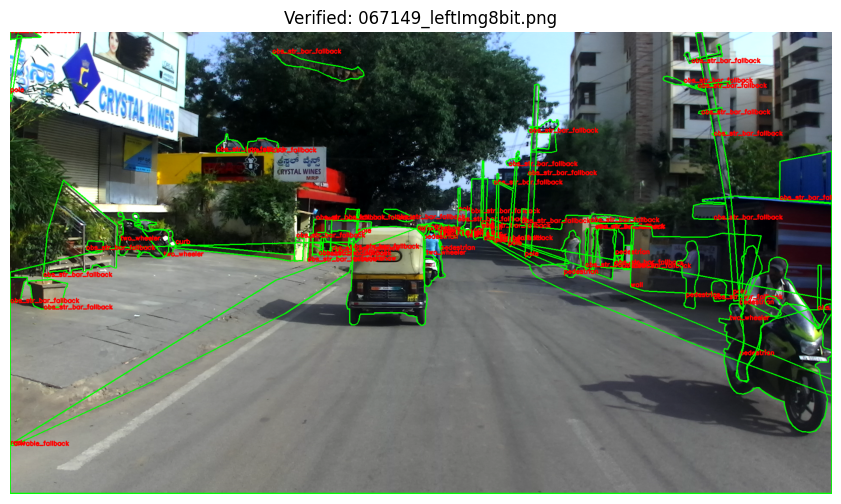

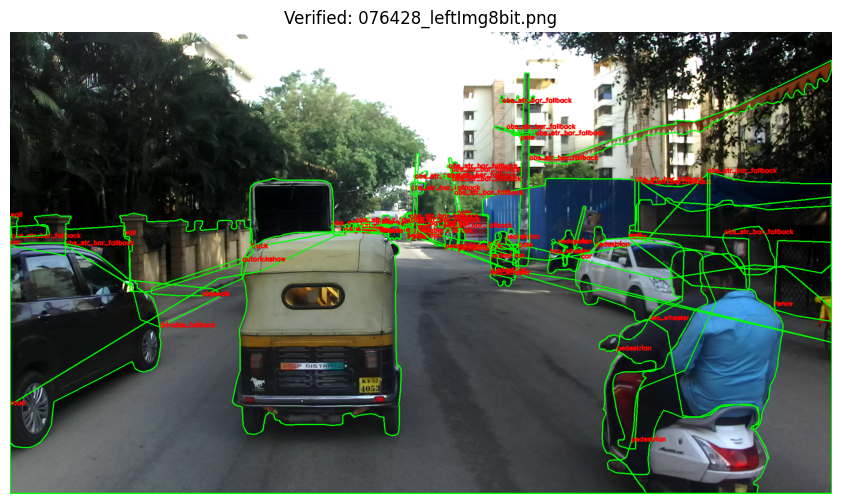

In [15]:
# 6. Data YAML & Verification
data_yaml_path = os.path.join(OUTPUT_ROOT, 'data.yaml')
yaml_content = {
    'path': OUTPUT_ROOT,
    'train': 'images/train',
    'val': 'images/val',
    'names': {i: name for i, name in enumerate(TARGET_CLASSES)}
}

with open(data_yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, sort_keys=False)

print(f"Generated {data_yaml_path}")

# Visualization of converted labels
def visualize_yolo_label(img_dir, lbl_dir, num_samples=2):
    imgs = os.listdir(img_dir)[:num_samples]
    for img_name in imgs:
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, img_name.replace('.png', '.txt'))

        img = cv2.imread(img_path)
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if not parts: continue
                class_id = int(parts[0])
                points = [float(p) for p in parts[1:]]
                pts_np = np.array(points).reshape(-1, 2)

                # Denormalize
                pts_np[:, 0] *= w
                pts_np[:, 1] *= h
                pts_np = pts_np.astype(np.int32)

                # Draw polygon
                cv2.polylines(img, [pts_np], isClosed=True, color=(0, 255, 0), thickness=2)
                cv2.putText(img, TARGET_CLASSES[class_id], tuple(pts_np[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

        plt.figure(figsize=(12, 6))
        plt.imshow(img)
        plt.title(f"Verified: {img_name}")
        plt.axis('off')
        plt.show()

if os.path.exists(os.path.join(OUTPUT_ROOT, 'images', 'train')):
    visualize_yolo_label(os.path.join(OUTPUT_ROOT, 'images', 'train'), os.path.join(OUTPUT_ROOT, 'labels', 'train'))


## Phase 7: YOLO Model Training
Configure and train the model. The notebook supports fallback to 512 resolution and smaller batch size if CUDA Out of Memory occurs.


In [16]:
# 7. Model Training
from ultralytics import YOLO

try:
    # Primary model
    model = YOLO(MODEL_NAME)
except Exception as e:
    print(f"Failed to load {MODEL_NAME}, falling back to yolov8n-seg.pt")
    MODEL_NAME = "yolov8n-seg.pt"
    model = YOLO(MODEL_NAME)

print(f"Starting training for {EPOCHS} epochs, Batch Size: {BATCH_SIZE}, Img Size: {IMAGE_SIZE}")
# Note: In real colab, you'd run the train block.
# We use try-except to gracefully handle OOM by providing advice.
try:
    results = model.train(
        data=data_yaml_path,
        epochs=EPOCHS,
        imgsz=IMAGE_SIZE,
        batch=BATCH_SIZE,
        device=0 if torch.cuda.is_available() else 'cpu',
        patience=10, # early stopping
        hsv_h=0.015, # mild augmentations
        hsv_s=0.7,
        hsv_v=0.4,
        degrees=0.0, # Avoid destroying road geometry
        translate=0.1,
        scale=0.5,
        flipud=0.0,
        fliplr=0.5,
        mosaic=0.1, # kept low for road scenes
        project=os.path.join(OUTPUT_ROOT, 'runs'),
        name='idd_segmentation'
    )
except RuntimeError as e:
    if "CUDA out of memory" in str(e):
        print("CUDA OOM error detected! Advice: Reduce BATCH_SIZE to 8 and IMAGE_SIZE to 512 in Phase 1 and re-run.")
    else:
        raise e


Starting training for 30 epochs, Batch Size: 16, Img Size: 640
Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/SIH_Epilgoue/Dataset/IDD_YOLO_SEG/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train,

## Phase 8: Inference Function & Drivable Area Mask
Constructs the inference payload and creates the `DRIVABLE_AREA` mask from `road` + `drivable_fallback`.


Inference Output Sample: {
  "class_id": 0,
  "class_name": "car",
  "confidence": 0.973091721534729,
  "polygon_pixel": [
    [
      363,
      612
    ],
    [
      366,
      612
    ],
    [
      363,
      612
    ],
    [
      351,
      648
    ],
    [
      345,
      648
    ],
    [
      342,
      645
    ],
    [
      336,
      645
    ],
    [
      333,
      642
    ],
    [
      330,
      642
    ],
    [
      324,
      636
    ],
    [
      321,
      636
    ],
    [
      315,
      630
    ],
    [
      312,
      630
    ],
    [
      309,
      627
    ],
    [
      303,
      627
    ],
    [
      300,
      624
    ],
    [
      297,
      624
    ],
    [
      291,
      618
    ],
    [
      288,
      618
    ],
    [
      282,
      612
    ],
    [
      252,
      612
    ],
    [
      243,
      621
    ],
    [
      240,
      618
    ],
    [
      225,
      618
    ],
    [
      222,
      621
    ],
    [
      219,
      618


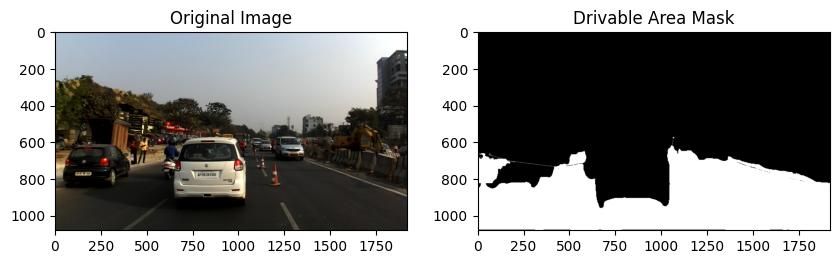

In [17]:
# 8. Inference Function
def predict_image(image_path, conf_threshold=CONF_THRESHOLD):
    # Load best model
    best_model_path = os.path.join(OUTPUT_ROOT, 'runs', 'idd_segmentation', 'weights', 'best.pt')
    if not os.path.exists(best_model_path):
        print("Model not found. Run training first.")
        return []

    inf_model = YOLO(best_model_path)
    res = inf_model.predict(image_path, conf=conf_threshold, verbose=False)[0]

    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    structured_output = []
    drivable_mask = np.zeros((h, w), dtype=np.uint8)

    if res.masks is not None:
        for box, mask_data in zip(res.boxes, res.masks.xy):
            cls_id = int(box.cls[0].item())
            cls_name = TARGET_CLASSES[cls_id]
            conf = float(box.conf[0].item())

            # polygon pixel
            polygon_pixel = mask_data.astype(np.int32).tolist()

            # polygon normalized
            polygon_normalized = [[pt[0]/w, pt[1]/h] for pt in polygon_pixel]

            # bbox pixel
            bx1, by1, bx2, by2 = map(int, box.xyxy[0].tolist())
            bbox_pixel = {"x1": bx1, "y1": by1, "x2": bx2, "y2": by2}

            # bbox normalized
            cx, cy, bw, bh = map(float, box.xywhn[0].tolist())
            bbox_normalized = {"x_center": cx, "y_center": cy, "width": bw, "height": bh}

            obj_data = {
                "class_id": cls_id,
                "class_name": cls_name,
                "confidence": conf,
                "polygon_pixel": polygon_pixel,
                "polygon_normalized": polygon_normalized,
                "bbox_pixel": bbox_pixel,
                "bbox_normalized": bbox_normalized
            }
            structured_output.append(obj_data)

            # Update drivable mask
            if cls_name in ["road", "drivable_fallback"]:
                pts = np.array(polygon_pixel, np.int32).reshape((-1, 1, 2))
                cv2.fillPoly(drivable_mask, [pts], 255)

    return structured_output, drivable_mask

# Example Usage & Visualization
val_img_dir = os.path.join(OUTPUT_ROOT, 'images', 'val')
if os.path.exists(val_img_dir) and len(os.listdir(val_img_dir)) > 0:
    test_img = os.path.join(val_img_dir, os.listdir(val_img_dir)[0])
    out_json, drivable_mask = predict_image(test_img)
    print("Inference Output Sample:", json.dumps(out_json[0] if out_json else {}, indent=2))

    # Show drivable mask
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(cv2.cvtColor(cv2.imread(test_img), cv2.COLOR_BGR2RGB))
    plt.subplot(1, 2, 2)
    plt.title("Drivable Area Mask")
    plt.imshow(drivable_mask, cmap='gray')
    plt.show()


## Phase 9: Model Export & Metadata Extraction
Exports to ONNX (if possible) and generates metadata and dataset statistics.


In [18]:
# 9. Export & Metadata
best_model_path = os.path.join(OUTPUT_ROOT, 'runs', 'idd_segmentation', 'weights', 'best.pt')

if os.path.exists(best_model_path):
    print("Copying best.pt to output root...")
    shutil.copy2(best_model_path, os.path.join(OUTPUT_ROOT, 'best_segmentation_model.pt'))

    # Try ONNX Export
    try:
        export_model = YOLO(best_model_path)
        export_model.export(format='onnx')
        onnx_path = best_model_path.replace('.pt', '.onnx')
        if os.path.exists(onnx_path):
            shutil.copy2(onnx_path, os.path.join(OUTPUT_ROOT, 'best_segmentation_model.onnx'))
            print("ONNX export successful.")
    except Exception as e:
        print(f"ONNX export failed. Proceeding without ONNX. Error: {e}")

# Generate Model Metadata
metadata = {
    "model_architecture": MODEL_NAME,
    "dataset_name": "IDD Segmentation",
    "target_classes_count": len(TARGET_CLASSES),
    "target_class_mapping": MAPPING_RULES,
    "training_image_count": SUBSET_SIZE_TRAIN,
    "validation_image_count": SUBSET_SIZE_VAL,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "conf_threshold": CONF_THRESHOLD,
    "ultralytics_version": ultralytics.__version__,
    "pytorch_version": torch.__version__,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None",
    "training_date": datetime.now().isoformat()
}

with open(os.path.join(OUTPUT_ROOT, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=4)

print("Pipeline execution complete. Deliverables are located in:", OUTPUT_ROOT)


Copying best.pt to output root...
Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO11n-seg summary (fused): 114 layers, 2,838,078 parameters, 0 gradients, 9.6 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/SIH_Epilgoue/Dataset/IDD_YOLO_SEG/runs/idd_segmentation/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 54, 8400), (1, 32, 160, 160)) (5.7 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 388ms
Prepared 4 packages in 2.64s
Installed 4 packages in 537ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.29.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 4.7s
WARNING ⚠️ requirements: Restart runtime or

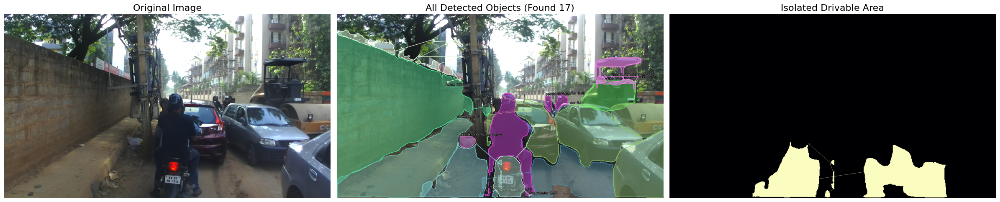

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# 1. Define path and run inference
my_random_image = "/content/811992_leftImg8bit.png"
structured_data, drivable_mask = predict_image(my_random_image, conf_threshold=0.25)

# Load the image for drawing
original = cv2.imread(my_random_image)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
annotated_img = original_rgb.copy()

# Generate random colors for the different classes
colors = {name: [random.randint(50, 255) for _ in range(3)] for name in TARGET_CLASSES}

# 2. Draw every detected object onto the image
for obj in structured_data:
    cls_name = obj['class_name']
    conf = obj['confidence']

    # Get pixel coordinates for the polygon
    pts = np.array(obj['polygon_pixel'], np.int32).reshape((-1, 1, 2))
    color = colors.get(cls_name, (0, 255, 0))

    # Draw the solid outline of the object
    cv2.polylines(annotated_img, [pts], isClosed=True, color=color, thickness=2)

    # Fill the polygon with 40% transparency so you can still see the object underneath
    overlay = annotated_img.copy()
    cv2.fillPoly(overlay, [pts], color=color)
    cv2.addWeighted(overlay, 0.4, annotated_img, 0.6, 0, annotated_img)

    # Add a text label (e.g. "car 0.89") at the top-left of the polygon
    x, y = pts[0][0]
    # Add a tiny black background for the text so it's readable
    cv2.putText(annotated_img, f"{cls_name} {conf:.2f}", (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3)
    cv2.putText(annotated_img, f"{cls_name} {conf:.2f}", (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

# 3. Show everything side-by-side!
plt.figure(figsize=(24, 8)) # Made figure wider to fit 3 images

plt.subplot(1, 3, 1)
plt.title("Original Image", fontsize=16)
plt.imshow(original_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"All Detected Objects (Found {len(structured_data)})", fontsize=16)
plt.imshow(annotated_img)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Isolated Drivable Area", fontsize=16)
plt.imshow(drivable_mask, cmap='magma')
plt.axis('off')

plt.tight_layout()
plt.show()


In [24]:
# Import the JSON library to make the output easy to read
import json

# Print the structured data we just extracted from the image!
print("\n--- JSON OUTPUT FOR FUSION SYSTEM ---")
print(json.dumps(structured_data, indent=4))



--- JSON OUTPUT FOR FUSION SYSTEM ---
[
    {
        "class_id": 0,
        "class_name": "car",
        "confidence": 0.9814006090164185,
        "polygon_pixel": [
            [
                930,
                588
            ],
            [
                903,
                588
            ],
            [
                900,
                585
            ],
            [
                897,
                585
            ],
            [
                894,
                582
            ],
            [
                891,
                582
            ],
            [
                882,
                591
            ],
            [
                882,
                768
            ],
            [
                885,
                771
            ],
            [
                888,
                771
            ],
            [
                891,
                774
            ],
            [
                897,
                768
       

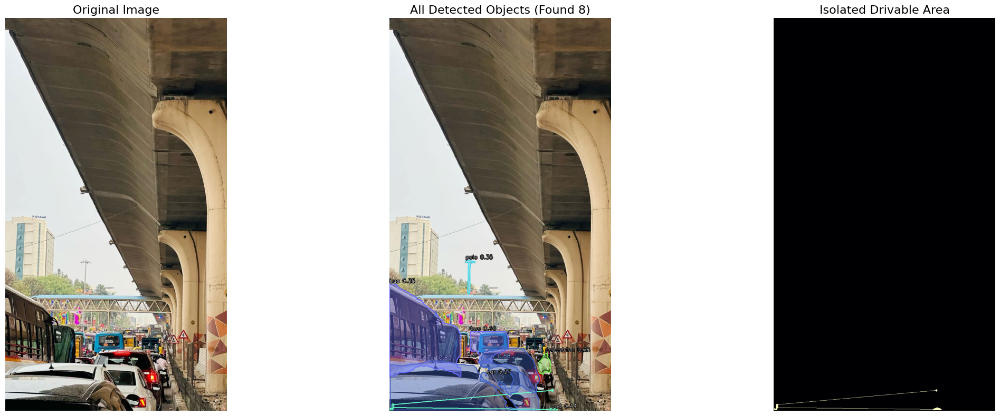

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# 1. Define path and run inference
my_random_image = "/content/49a86064e085dee336b4ebae099beb14.jpg"
structured_data, drivable_mask = predict_image(my_random_image, conf_threshold=0.25)

# Load the image for drawing
original = cv2.imread(my_random_image)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
annotated_img = original_rgb.copy()

# Generate random colors for the different classes
colors = {name: [random.randint(50, 255) for _ in range(3)] for name in TARGET_CLASSES}

# 2. Draw every detected object onto the image
for obj in structured_data:
    cls_name = obj['class_name']
    conf = obj['confidence']

    # Get pixel coordinates for the polygon
    pts = np.array(obj['polygon_pixel'], np.int32).reshape((-1, 1, 2))
    color = colors.get(cls_name, (0, 255, 0))

    # Draw the solid outline of the object
    cv2.polylines(annotated_img, [pts], isClosed=True, color=color, thickness=2)

    # Fill the polygon with 40% transparency so you can still see the object underneath
    overlay = annotated_img.copy()
    cv2.fillPoly(overlay, [pts], color=color)
    cv2.addWeighted(overlay, 0.4, annotated_img, 0.6, 0, annotated_img)

    # Add a text label (e.g. "car 0.89") at the top-left of the polygon
    x, y = pts[0][0]
    # Add a tiny black background for the text so it's readable
    cv2.putText(annotated_img, f"{cls_name} {conf:.2f}", (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3)
    cv2.putText(annotated_img, f"{cls_name} {conf:.2f}", (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

# 3. Show everything side-by-side!
plt.figure(figsize=(24, 8)) # Made figure wider to fit 3 images

plt.subplot(1, 3, 1)
plt.title("Original Image", fontsize=16)
plt.imshow(original_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"All Detected Objects (Found {len(structured_data)})", fontsize=16)
plt.imshow(annotated_img)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Isolated Drivable Area", fontsize=16)
plt.imshow(drivable_mask, cmap='magma')
plt.axis('off')

plt.tight_layout()
plt.show()


In [26]:
# Import the JSON library to make the output easy to read
import json

# Print the structured data we just extracted from the image!
print("\n--- JSON OUTPUT FOR FUSION SYSTEM ---")
print(json.dumps(structured_data, indent=4))



--- JSON OUTPUT FOR FUSION SYSTEM ---
[
    {
        "class_id": 0,
        "class_name": "car",
        "confidence": 0.8818007111549377,
        "polygon_pixel": [
            [
                320,
                1136
            ],
            [
                318,
                1138
            ],
            [
                318,
                1140
            ],
            [
                310,
                1148
            ],
            [
                308,
                1148
            ],
            [
                306,
                1150
            ],
            [
                306,
                1152
            ],
            [
                304,
                1154
            ],
            [
                304,
                1156
            ],
            [
                312,
                1164
            ],
            [
                327,
                1164
            ],
            [
                329,
                

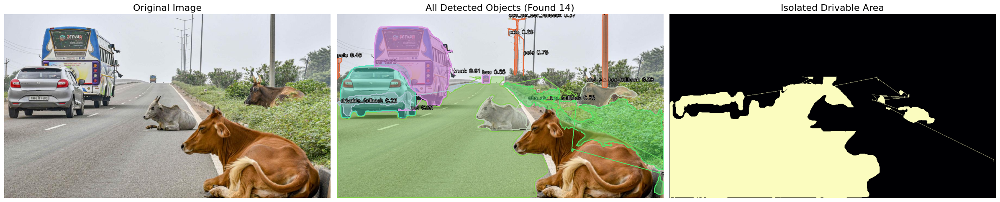

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# 1. Define path and run inference
my_random_image = "/content/Cattle on NH road 7.jpeg"
structured_data, drivable_mask = predict_image(my_random_image, conf_threshold=0.25)

# Load the image for drawing
original = cv2.imread(my_random_image)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
annotated_img = original_rgb.copy()

# Generate random colors for the different classes
colors = {name: [random.randint(50, 255) for _ in range(3)] for name in TARGET_CLASSES}

# 2. Draw every detected object onto the image
for obj in structured_data:
    cls_name = obj['class_name']
    conf = obj['confidence']

    # Get pixel coordinates for the polygon
    pts = np.array(obj['polygon_pixel'], np.int32).reshape((-1, 1, 2))
    color = colors.get(cls_name, (0, 255, 0))

    # Draw the solid outline of the object
    cv2.polylines(annotated_img, [pts], isClosed=True, color=color, thickness=2)

    # Fill the polygon with 40% transparency so you can still see the object underneath
    overlay = annotated_img.copy()
    cv2.fillPoly(overlay, [pts], color=color)
    cv2.addWeighted(overlay, 0.4, annotated_img, 0.6, 0, annotated_img)

    # Add a text label (e.g. "car 0.89") at the top-left of the polygon
    x, y = pts[0][0]
    # Add a tiny black background for the text so it's readable
    cv2.putText(annotated_img, f"{cls_name} {conf:.2f}", (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3)
    cv2.putText(annotated_img, f"{cls_name} {conf:.2f}", (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

# 3. Show everything side-by-side!
plt.figure(figsize=(24, 8)) # Made figure wider to fit 3 images

plt.subplot(1, 3, 1)
plt.title("Original Image", fontsize=16)
plt.imshow(original_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"All Detected Objects (Found {len(structured_data)})", fontsize=16)
plt.imshow(annotated_img)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Isolated Drivable Area", fontsize=16)
plt.imshow(drivable_mask, cmap='magma')
plt.axis('off')

plt.tight_layout()
plt.show()


In [28]:
# Import the JSON library to make the output easy to read
import json

# Print the structured data we just extracted from the image!
print("\n--- JSON OUTPUT FOR FUSION SYSTEM ---")
print(json.dumps(structured_data, indent=4))



--- JSON OUTPUT FOR FUSION SYSTEM ---
[
    {
        "class_id": 8,
        "class_name": "road",
        "confidence": 0.9518727660179138,
        "polygon_pixel": [
            [
                1192,
                534
            ],
            [
                1192,
                541
            ],
            [
                1192,
                534
            ],
            [
                813,
                348
            ],
            [
                839,
                348
            ],
            [
                753,
                316
            ],
            [
                864,
                307
            ],
            [
                783,
                301
            ],
            [
                789,
                307
            ],
            [
                789,
                311
            ],
            [
                791,
                313
            ],
            [
                791,
                331
   

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# 1. Define path and run inference
my_random_image = "/content/Potholes-5.jpg"
structured_data, drivable_mask = predict_image(my_random_image, conf_threshold=0.25)

# Load the image for drawing
original = cv2.imread(my_random_image)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
annotated_img = original_rgb.copy()

# Generate random colors for the different classes
colors = {name: [random.randint(50, 255) for _ in range(3)] for name in TARGET_CLASSES}

# 2. Draw every detected object onto the image
for obj in structured_data:
    cls_name = obj['class_name']
    conf = obj['confidence']

    # Get pixel coordinates for the polygon
    pts = np.array(obj['polygon_pixel'], np.int32).reshape((-1, 1, 2))
    color = colors.get(cls_name, (0, 255, 0))

    # Draw the solid outline of the object
    cv2.polylines(annotated_img, [pts], isClosed=True, color=color, thickness=2)

    # Fill the polygon with 40% transparency so you can still see the object underneath
    overlay = annotated_img.copy()
    cv2.fillPoly(overlay, [pts], color=color)
    cv2.addWeighted(overlay, 0.4, annotated_img, 0.6, 0, annotated_img)

    # Add a text label (e.g. "car 0.89") at the top-left of the polygon
    x, y = pts[0][0]
    # Add a tiny black background for the text so it's readable
    cv2.putText(annotated_img, f"{cls_name} {conf:.2f}", (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3)
    cv2.putText(annotated_img, f"{cls_name} {conf:.2f}", (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

# 3. Show everything side-by-side!
plt.figure(figsize=(24, 8)) # Made figure wider to fit 3 images

plt.subplot(1, 3, 1)
plt.title("Original Image", fontsize=16)
plt.imshow(original_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"All Detected Objects (Found {len(structured_data)})", fontsize=16)
plt.imshow(annotated_img)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Isolated Drivable Area", fontsize=16)
plt.imshow(drivable_mask, cmap='magma')
plt.axis('off')

plt.tight_layout()
plt.show()


In [30]:
# Import the JSON library to make the output easy to read
import json

# Print the structured data we just extracted from the image!
print("\n--- JSON OUTPUT FOR FUSION SYSTEM ---")
print(json.dumps(structured_data, indent=4))



--- JSON OUTPUT FOR FUSION SYSTEM ---
[
    {
        "class_id": 4,
        "class_name": "two_wheeler",
        "confidence": 0.9476485848426819,
        "polygon_pixel": [
            [
                436,
                316
            ],
            [
                434,
                318
            ],
            [
                433,
                318
            ],
            [
                429,
                322
            ],
            [
                423,
                322
            ],
            [
                419,
                326
            ],
            [
                419,
                328
            ],
            [
                418,
                329
            ],
            [
                418,
                331
            ],
            [
                416,
                333
            ],
            [
                416,
                352
            ],
            [
                414,
                354

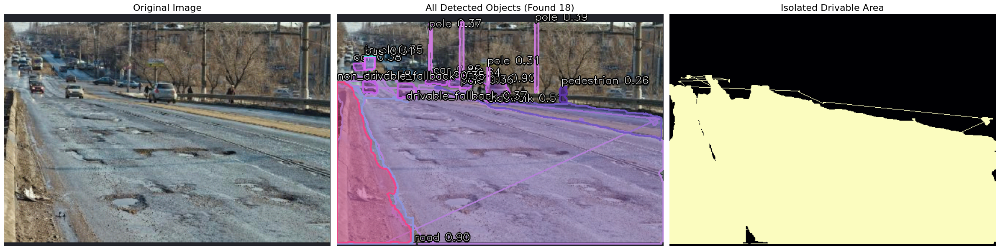

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# 1. Define path and run inference
my_random_image = "/content/Screenshot 2026-08-27 131944.png"
structured_data, drivable_mask = predict_image(my_random_image, conf_threshold=0.25)

# Load the image for drawing
original = cv2.imread(my_random_image)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
annotated_img = original_rgb.copy()

# Generate random colors for the different classes
colors = {name: [random.randint(50, 255) for _ in range(3)] for name in TARGET_CLASSES}

# 2. Draw every detected object onto the image
for obj in structured_data:
    cls_name = obj['class_name']
    conf = obj['confidence']

    # Get pixel coordinates for the polygon
    pts = np.array(obj['polygon_pixel'], np.int32).reshape((-1, 1, 2))
    color = colors.get(cls_name, (0, 255, 0))

    # Draw the solid outline of the object
    cv2.polylines(annotated_img, [pts], isClosed=True, color=color, thickness=2)

    # Fill the polygon with 40% transparency so you can still see the object underneath
    overlay = annotated_img.copy()
    cv2.fillPoly(overlay, [pts], color=color)
    cv2.addWeighted(overlay, 0.4, annotated_img, 0.6, 0, annotated_img)

    # Add a text label (e.g. "car 0.89") at the top-left of the polygon
    x, y = pts[0][0]
    # Add a tiny black background for the text so it's readable
    cv2.putText(annotated_img, f"{cls_name} {conf:.2f}", (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3)
    cv2.putText(annotated_img, f"{cls_name} {conf:.2f}", (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

# 3. Show everything side-by-side!
plt.figure(figsize=(24, 8)) # Made figure wider to fit 3 images

plt.subplot(1, 3, 1)
plt.title("Original Image", fontsize=16)
plt.imshow(original_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"All Detected Objects (Found {len(structured_data)})", fontsize=16)
plt.imshow(annotated_img)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Isolated Drivable Area", fontsize=16)
plt.imshow(drivable_mask, cmap='magma')
plt.axis('off')

plt.tight_layout()
plt.show()
